# 15 ST-TR: final results

The spatial temporal transformer baseline, after Plizzari et al. (2021). Where the Transformer Encoder
treats each frame as one token and has no notion of the skeleton, ST-TR attends over the skeleton directly:
spatial self attention relates the joints within each frame, temporal self attention relates the frames
within each joint, and the two replace ST-GCN's graph convolution and temporal convolution in a backbone of
the same shape (nine blocks, 64 to 128 to 256 channels, temporal stride 2 at blocks 4 and 7).

**Single stream, not an ensemble.** The original work trains a spatial stream and a temporal stream
separately and ensembles their scores. Here the two attention types sit in the same blocks, the single
stream variant the authors also describe, so the result is one model and can be compared with the others
without mixing an ensemble into a single model table. This is an implementation of the documented design,
not the authors' released code, and the methods section should say so.

**What changed from the first version of this model.** The first version had no positional information, so
attention could not tell frame order or joint identity, and it reached 63.4% top 1 and 52.1% MCA. Learned
positional embeddings are now added, one per joint inside spatial attention and one per frame inside temporal
attention, sized for the frames each block actually sees (30, 15 and 7). The smoke test checks that shuffling
frame order now changes the output.

**Input.** `body_court`, as for every other model: (x, y, confidence, bone dx, bone dy, court x, court y)
per joint, laid out as channels by frames by joints.

**Recipe.** Attention models need AdamW rather than the SGD that suits ST-GCN (the first attempt produced
NaNs under SGD). Learning rate 1e-4 is the value verified stable for this architecture, with a 5 epoch warmup
into cosine decay, weight decay 0.05, label smoothing 0.1 and gradient clipping at 1.0, the same
regularisation as the Transformer Encoder. The class balanced sampler floor (300 per class) and the advanced
augmentation policy are carried over unchanged.

**Scope.** 3 seeds (42, 123, 7) times 2 augmentation conditions (advanced, none): 6 runs, each reporting on
train, val and test, logged to `BadmintonPoseAnalysis/models/STTR`.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds
from models import sttr as sttr_model
from models.transformer import warmup_cosine_scheduler
import training as tr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

2.1.0+cu118 cuda NVIDIA GeForce RTX 4090


In [2]:
PROJECT = "BadmintonPoseAnalysis/models/STTR"
KEYPOINTS = f"{DATA}/keypoints_interp"
OUT = os.environ.get("BADMINTON_OUTPUTS", "/workspace/outputs") + "/models/sttr"
os.makedirs(OUT, exist_ok=True)

SEEDS = [42, 123, 7]
SPLITS = ("train", "val", "test")
NORMALISATION, USE_COURT = "body", True
NUM_WORKERS, EVAL_WORKERS = 20, 8

RECIPE = {
    "model": "ST-TR (single stream)", "normalisation": "body_court", "num_heads": 8, "dropout": 0.1,
    "min_native_frames": 5, "batch_size": 32, "lr": 1e-4, "weight_decay": 0.05, "label_smoothing": 0.1,
    "warmup_epochs": 5, "num_epochs": 60, "patience": 15, "select_metric": "top1", "target_per_class": 300,
    "grad_clip": 1.0,
}
CONDITIONS = {"advanced": "advanced", "none": "none"}

# reference points for the comparison plot (test, advanced augmentation, notebooks 06, 09, 11)
STGCN_FINAL = {"top1": 0.7229, "top5": 0.9437, "mca": 0.6121}
LSTM_FINAL = {"top1": 0.6952, "top5": 0.9309, "mca": 0.5794}
TRANSFORMER_FINAL = {"top1": 0.6820, "top5": 0.9216, "mca": 0.5498}
NO_MOTION_PROBE = {"top1": 0.549, "mca": 0.429}

In [3]:
manifest = ds.load_filtered_manifest(f"{DATA}/split_manifest.csv", f"{DATA}/extraction_log.csv",
                                     f"{DATA}/keypoints_interp_log.csv", RECIPE["min_native_frames"])
class_names = sorted(manifest["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
split_hash = open(f"{DATA}/split_manifest.sha256").read().split()[0]
forward = sttr_model.make_forward(USE_COURT)
in_ch = sttr_model.in_channels(USE_COURT)

manual review: dropped 4 clips
short clip rule: dropped 4 train clips with fewer than 5 real frames
7810 clips remain (train 6247, test 782, val 781)


## Smoke test

Run alone first: checks the flattened input shape, the [CLS] token and positional embedding produce a
valid forward pass, every parameter gets a gradient, and the warmup+cosine schedule actually ramps up then
decays (a wrong milestone here silently trains at the wrong learning rate for the whole run).

In [4]:
tr.seed_everything(0)
loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, "advanced", NORMALISATION, seed=0,
                           batch_size=RECIPE["batch_size"], target_per_class=300, num_workers=2, eval_workers=2)
model = sttr_model.build_sttr(in_ch, len(class_names), RECIPE["dropout"], RECIPE["num_heads"]).to(device)
print(f"input channels {in_ch}, parameters {sum(p.numel() for p in model.parameters()):,}, "
      f"frames seen by each block {model.frames_per_block}")

batch = next(iter(loaders["train"]))
logits = forward(model, batch, device)
assert logits.shape == (RECIPE["batch_size"], len(class_names)), logits.shape
nn.CrossEntropyLoss(label_smoothing=RECIPE["label_smoothing"])(logits, batch["label"].to(device)).backward()
missing = [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]
assert not missing, missing

# positional embeddings must make the model order sensitive (the first version was not)
model.eval()
with torch.no_grad():
    x = torch.cat([batch["keypoints"], batch["bone"],
                   batch["court"][:, :, None, :].expand(-1, -1, 17, -1)], dim=-1).float().permute(0, 3, 1, 2).to(device)
    base = model(x)
    shuffled_frames = model(x[:, :, torch.randperm(x.shape[2])])
assert (base - shuffled_frames).abs().max() > 1e-4, "output ignores frame order"
print("frame order changes the output: positional embeddings are working")
model.train()

opt = torch.optim.AdamW(model.parameters(), lr=RECIPE["lr"], weight_decay=RECIPE["weight_decay"])
sched = warmup_cosine_scheduler(opt, RECIPE["warmup_epochs"], RECIPE["num_epochs"])
lrs = []
for _ in range(RECIPE["num_epochs"]):
    lrs.append(opt.param_groups[0]["lr"])
    sched.step()
print("lr at epoch 0/4/5/30/59:", [f"{lrs[e]:.2e}" for e in (0, 4, 5, 30, 59)])
assert lrs[5] > lrs[0] and lrs[-1] < lrs[5], "warmup/decay shape looks wrong"

# a short real training burst: loss must stay finite (an earlier version produced NaN under the wrong optimiser)
crit = nn.CrossEntropyLoss(label_smoothing=RECIPE["label_smoothing"])
y = batch["label"].to(device)
for step in range(20):
    opt.zero_grad()
    loss = crit(forward(model, batch, device), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), RECIPE["grad_clip"])
    opt.step()
    assert torch.isfinite(loss), f"non finite loss at step {step}"
print(f"20 steps on one batch: loss finite, final {loss.item():.3f}")

before = tr.evaluate(model, loaders["val"], forward, device)
print(f"untrained val top1 {before['top1']:.3f}")
del model, loaders
print("smoke test passed")

input channels 7, parameters 2,212,050, frames seen by each block [30, 30, 30, 30, 15, 15, 15, 7, 7]
frame order changes the output: positional embeddings are working


/workspace/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
/workspace/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:149: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: htt

lr at epoch 0/4/5/30/59: ['1.00e-05', '8.20e-05', '1.00e-04', '5.71e-05', '8.15e-08']
20 steps on one batch: loss finite, final 3.534
untrained val top1 0.019
smoke test passed


## Runs

3 seeds times 2 augmentation conditions: 6 runs. Results are appended after every run and finished runs
are skipped, so the cell is safe to re-run after an interruption.

In [5]:
results_path = f"{OUT}/results.csv"
done = pd.read_csv(results_path) if os.path.exists(results_path) else pd.DataFrame(columns=["condition", "seed"])

for cond_name, aug_policy in CONDITIONS.items():
    for seed in SEEDS:
        if ((done["condition"] == cond_name) & (done["seed"] == seed)).any():
            print(f"skip {cond_name} seed {seed}, already done")
            continue
        run_name = f"sttr_{cond_name}_s{seed}"
        print(f"\n=== {run_name} ===")
        tr.seed_everything(seed)

        task = Task.init(project_name=PROJECT, task_name=run_name, task_type=Task.TaskTypes.training,
                         tags=["sttr", cond_name, f"seed{seed}"], reuse_last_task_id=False,
                         auto_connect_frameworks={"matplotlib": False, "pytorch": False})
        task.connect({**RECIPE, "augmentation": aug_policy, "condition": cond_name, "seed": seed,
                      "keypoints": KEYPOINTS, "split_sha256": split_hash})

        loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, aug_policy, NORMALISATION, seed=seed,
                                   batch_size=RECIPE["batch_size"], target_per_class=RECIPE["target_per_class"],
                                   num_workers=NUM_WORKERS, eval_workers=EVAL_WORKERS)
        model = sttr_model.build_sttr(in_ch, len(class_names), RECIPE["dropout"], RECIPE["num_heads"]).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=RECIPE["lr"], weight_decay=RECIPE["weight_decay"])
        scheduler = warmup_cosine_scheduler(optimizer, RECIPE["warmup_epochs"], RECIPE["num_epochs"])
        criterion = nn.CrossEntropyLoss(label_smoothing=RECIPE["label_smoothing"])

        _, history, best_epoch = tr.train_model(model, forward, loaders, optimizer, scheduler, criterion, device,
                                                task.get_logger(), num_epochs=RECIPE["num_epochs"],
                                                patience=RECIPE["patience"], select_metric=RECIPE["select_metric"],
                                                splits=SPLITS, grad_clip=RECIPE["grad_clip"])
        metrics = tr.report_run(task, model, forward, loaders, class_names, device, history, best_epoch,
                                out_dir=f"{OUT}/{run_name}", run_name=run_name, splits=SPLITS, show=False,
                                extra={"condition": cond_name, "seed": seed})
        task.close()

        done = pd.concat([done, pd.DataFrame([metrics])], ignore_index=True)
        done.to_csv(results_path, index=False)
        del model, loaders
        torch.cuda.empty_cache()


=== sttr_advanced_s42 ===
ClearML Task: created new task id=2567f23a1f3a4f8eabbdd06cc3e01c42
2026-10-06 09:00:54,925 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/f88c3a2647c544148ca2f4e6c7b12443/tasks/2567f23a1f3a4f8eabbdd06cc3e01c42/output/log
epoch   0  loss 2.987  train 0.268  val 0.297 (mca 0.167)  *
epoch   1  loss 2.517  train 0.417  val 0.429 (mca 0.298)  *
epoch   2  loss 2.181  train 0.496  val 0.516 (mca 0.407)  *
epoch   3  loss 1.991  train 0.532  val 0.530 (mca 0.434)  *


/workspace/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:149: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


epoch   4  loss 1.855  train 0.595  val 0.576 (mca 0.468)  *
epoch   5  loss 1.741  train 0.636  val 0.611 (mca 0.519)  *
epoch   6  loss 1.638  train 0.632  val 0.616 (mca 0.522)  *
epoch   7  loss 1.524  train 0.700  val 0.653 (mca 0.536)  *
epoch   8  loss 1.439  train 0.718  val 0.676 (mca 0.597)  *
epoch   9  loss 1.373  train 0.738  val 0.688 (mca 0.604)  *
epoch  10  loss 1.293  train 0.746  val 0.688 (mca 0.620)
epoch  11  loss 1.244  train 0.787  val 0.700 (mca 0.614)  *
epoch  14  loss 1.086  train 0.831  val 0.702 (mca 0.611)  *
epoch  15  loss 1.054  train 0.861  val 0.707 (mca 0.610)  *
epoch  17  loss 0.965  train 0.900  val 0.723 (mca 0.626)  *
epoch  18  loss 0.935  train 0.911  val 0.730 (mca 0.631)  *
epoch  20  loss 0.874  train 0.937  val 0.729 (mca 0.642)
epoch  25  loss 0.756  train 0.980  val 0.726 (mca 0.614)
epoch  30  loss 0.690  train 0.995  val 0.727 (mca 0.618)
early stop at epoch 33, best val top1 0.7298 at epoch 18
train top1 0.9105 mca 0.9150 | val top1 

█████████████████████████████████ 100% | 8.49/8.49 MB [00:01<00:00,  7.18MB/s]: 



=== sttr_advanced_s123 ===


...

Failed accessing the jupyter server(s): []


ClearML Task: created new task id=3b97623a66504f15a7e0ba3660be1311
ClearML results page: https://app.clear.ml/projects/f88c3a2647c544148ca2f4e6c7b12443/tasks/3b97623a66504f15a7e0ba3660be1311/output/log
epoch   0  loss 2.994  train 0.270  val 0.268 (mca 0.160)  *
epoch   1  loss 2.522  train 0.439  val 0.452 (mca 0.319)  *
epoch   3  loss 1.996  train 0.527  val 0.516 (mca 0.400)  *


/workspace/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:149: UserWarning:

The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.



epoch   4  loss 1.851  train 0.597  val 0.590 (mca 0.498)  *
epoch   5  loss 1.723  train 0.623  val 0.593 (mca 0.511)  *
epoch   6  loss 1.622  train 0.664  val 0.635 (mca 0.538)  *
epoch   7  loss 1.511  train 0.694  val 0.662 (mca 0.555)  *
epoch   8  loss 1.418  train 0.729  val 0.698 (mca 0.618)  *
epoch  10  loss 1.285  train 0.774  val 0.699 (mca 0.614)  *
epoch  13  loss 1.107  train 0.845  val 0.707 (mca 0.617)  *
epoch  14  loss 1.060  train 0.844  val 0.720 (mca 0.613)  *
epoch  15  loss 1.023  train 0.864  val 0.711 (mca 0.617)
epoch  20  loss 0.835  train 0.948  val 0.704 (mca 0.602)
epoch  23  loss 0.758  train 0.982  val 0.723 (mca 0.621)  *
epoch  25  loss 0.719  train 0.984  val 0.700 (mca 0.618)
epoch  29  loss 0.667  train 0.996  val 0.731 (mca 0.624)  *
epoch  30  loss 0.655  train 0.998  val 0.717 (mca 0.609)
epoch  35  loss 0.628  train 1.000  val 0.721 (mca 0.617)
epoch  40  loss 0.613  train 1.000  val 0.712 (mca 0.605)
early stop at epoch 44, best val top1 0.73

█████████████████████████████████ 100% | 8.49/8.49 MB [00:01<00:00,  7.01MB/s]: 


## Summary

In [6]:
results = pd.read_csv(results_path)
summary = Task.init(project_name=PROJECT, task_name="sttr_summary", task_type=Task.TaskTypes.qc,
                    tags=["sttr", "summary"], reuse_last_task_id=False, auto_connect_frameworks={"matplotlib": False})
slog = summary.get_logger()
summary.connect({**RECIPE, "seeds": SEEDS, "conditions": list(CONDITIONS)})

metric_cols = ["test_top1", "test_top5", "test_mca", "test_macro_f1", "val_top1", "train_test_gap"]
table = tr.mean_std_table(results, ["condition"], metric_cols[:-1])
table["best_epoch"] = results.groupby("condition")["best_epoch"].mean().round(1).values
table = table.set_index("condition").loc[list(CONDITIONS)].reset_index()
slog.report_table("ST-TR results (mean ± std over seeds)", "test", iteration=0, table_plot=table)
for cond in CONDITIONS:
    sub = results[results["condition"] == cond]
    for m in ["test_top1", "test_top5", "test_mca", "test_macro_f1"]:
        slog.report_single_value(f"{cond}_{m}_mean", float(sub[m].mean()))
summary.upload_artifact("results", artifact_object=results_path)
table

Failed accessing the jupyter server(s): []


ClearML Task: created new task id=145ba54f320843809721cb175a7a7742
ClearML results page: https://app.clear.ml/projects/f88c3a2647c544148ca2f4e6c7b12443/tasks/145ba54f320843809721cb175a7a7742/output/log


,condition,test_top1,test_top5,test_mca,test_macro_f1,val_top1,seeds,best_epoch
0,advanced,68.76 ± 0.30,91.47 ± 1.19,56.11 ± 1.44,57.08 ± 1.50,72.64 ± 0.48,3,22.3
1,none,68.88 ± 1.29,89.60 ± 0.64,55.70 ± 2.16,57.45 ± 2.35,72.68 ± 0.85,3,27.7


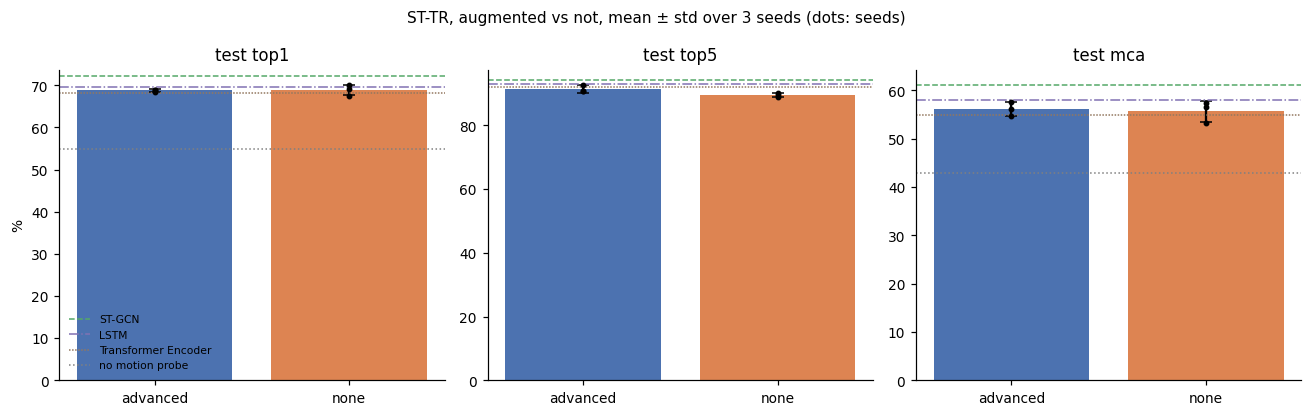

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, m, key, probe_key in zip(axes, ["test_top1", "test_top5", "test_mca"],
                                 ["top1", "top5", "mca"], ["top1", None, "mca"]):
    g = results.groupby("condition")[m]
    means, stds = g.mean().loc[list(CONDITIONS)], g.std().loc[list(CONDITIONS)]
    x = np.arange(len(CONDITIONS))
    ax.bar(x, 100 * means, yerr=100 * stds, capsize=4, color=["#4c72b0", "#dd8452"])
    for i, cond in enumerate(CONDITIONS):
        ax.scatter(np.full(len(SEEDS), i), 100 * results.loc[results["condition"] == cond, m], color="black", s=8, zorder=3)
    ax.axhline(100 * STGCN_FINAL[key], color="#55a868", ls="--", lw=1, label="ST-GCN")
    ax.axhline(100 * LSTM_FINAL[key], color="#8172b3", ls="-.", lw=1, label="LSTM")
    ax.axhline(100 * TRANSFORMER_FINAL[key], color="#937860", ls=(0, (1, 1)), lw=1, label="Transformer Encoder")
    if probe_key:
        ax.axhline(100 * NO_MOTION_PROBE[probe_key], color="grey", ls=":", lw=1, label="no motion probe")
    ax.set_xticks(x, list(CONDITIONS))
    ax.set_title(m.replace("test_", "test ").replace("_", " "))
axes[0].set_ylabel("%")
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("ST-TR, augmented vs not, mean ± std over 3 seeds (dots: seeds)", fontsize=10)
fig.tight_layout()
slog.report_matplotlib_figure("ST-TR vs other models and no motion probe", "test", figure=fig, iteration=0, report_interactive=False)
plt.show()

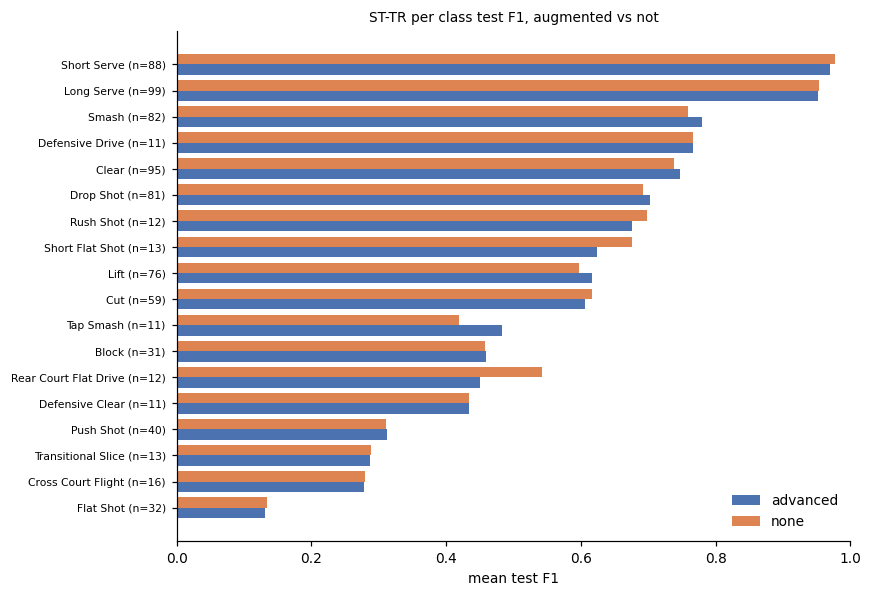

In [8]:
per_class = []
for _, r in results.iterrows():
    pc = pd.read_csv(f"{OUT}/{r['run']}/{r['run']}_per_class.csv")
    pc["condition"] = r["condition"]
    per_class.append(pc)
per_class = pd.concat(per_class)
pivot = per_class.groupby(["class", "condition"])["f1"].mean().unstack()[list(CONDITIONS)]
support = per_class.groupby("class")["support"].first()
order = pivot["advanced"].sort_values().index

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(order))
ax.barh(y - 0.2, pivot.loc[order, "advanced"], height=0.4, color="#4c72b0", label="advanced")
ax.barh(y + 0.2, pivot.loc[order, "none"], height=0.4, color="#dd8452", label="none")
ax.set_yticks(y, [f"{c} (n={support[c]})" for c in order], fontsize=7)
ax.set_xlabel("mean test F1")
ax.set_xlim(0, 1.0)
ax.legend(frameon=False)
ax.set_title("ST-TR per class test F1, augmented vs not", fontsize=9)
fig.tight_layout()
slog.report_matplotlib_figure("ST-TR per class F1", "test", figure=fig, iteration=0, report_interactive=False)
plt.show()
slog.report_table("per class F1 by condition", "test", iteration=0, table_plot=pivot.reset_index())
summary.close()

## Reading the result

- The useful comparisons are against the Transformer Encoder (same family, no skeleton structure) and
  ST-GCN (skeleton structure through graph convolution). If ST-TR clearly beats the Transformer Encoder, the
  skeleton aware attention is paying for itself; if it sits close to it, joint level attention is not adding
  much on this dataset. If it reaches ST-GCN, attention is a viable replacement for the graph.
- The first version scored 63.4% top 1 and 52.1% MCA without positional embeddings. A clear improvement over
  that confirms the missing order information was the cause, and is worth stating in the methods section.
- As with the other baselines, clearing the no motion probe comfortably is the basic sanity check.